In [16]:
from pathlib import Path
import numpy as np

cloud_file = Path("data/raw/satellite/ireland_clouds_20240101_20250101.npz")

print("File found:", cloud_file.exists())

with np.load(cloud_file) as data:
    lat=data["lat"][:]
    lon=data["lon"][:]
    for name in data.files:
        print(name, "shape:", data[name].shape, "type:", data[name].dtype)

File found: True
times shape: (8784,) type: datetime64[us]
cloud_mask shape: (8784, 90, 120) type: uint8
cth_km shape: (8784, 90, 120) type: float16
lat shape: (90,) type: float64
lon shape: (120,) type: float64


In [17]:
with np.load(cloud_file) as data:
    time = data["times"][0]
    mask = data["cloud_mask"][0]
    height = data["cth_km"][0]
    lat_range = (data["lat"][0], data["lat"][-1])
    lon_range = (data["lon"][0], data["lon"][-1])

print("Time:", time)
print("Cloud mask values and counts:", np.unique(mask, return_counts=True))
print("Cloud-top height range (km):", np.nanmin(height), "to", np.nanmax(height))
print("Latitude range:", lat_range)
print("Longitude range:", lon_range)

Time: 2024-01-01T00:00:00.000000
Cloud mask values and counts: (array([0, 1, 2, 3], dtype=uint8), array([1209, 2683, 6907,    1]))
Cloud-top height range (km): 0.0 to 9.92
Latitude range: (np.float64(55.475), np.float64(51.025))
Longitude range: (np.float64(-10.975), np.float64(-5.0249999999999995))


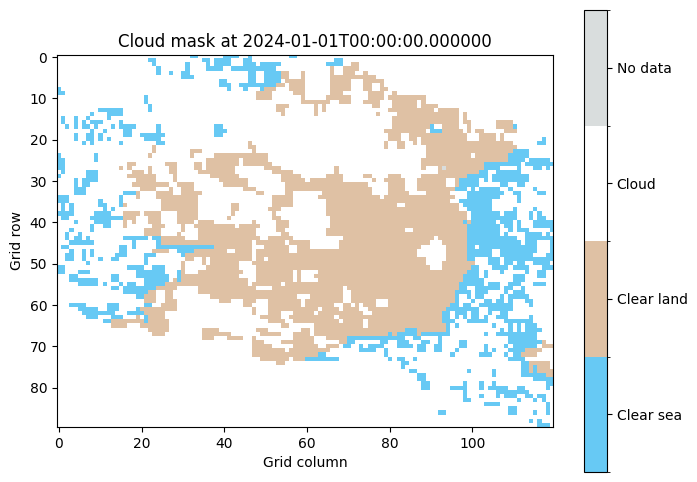

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

mask_colours = ListedColormap([
    "#67c9f4",  # 0: clear sea — light blue
    "#dfc1a4",  # 1: clear land — beige
    "#ffffff",  # 2: cloud — white
    "#d9dddd",  # 3: no data — light grey
])

boundaries = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(boundaries, mask_colours.N)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(mask, cmap=mask_colours, norm=norm)

colour_bar = fig.colorbar(image, ax=ax, ticks=[0, 1, 2, 3])
colour_bar.ax.set_yticklabels(["Clear sea", "Clear land", "Cloud", "No data"])

ax.set_title(f"Cloud mask at {time}")
ax.set_xlabel("Grid column")
ax.set_ylabel("Grid row")
plt.show()

In [10]:
%pip install cartopy

Note: you may need to restart the kernel to use updated packages.


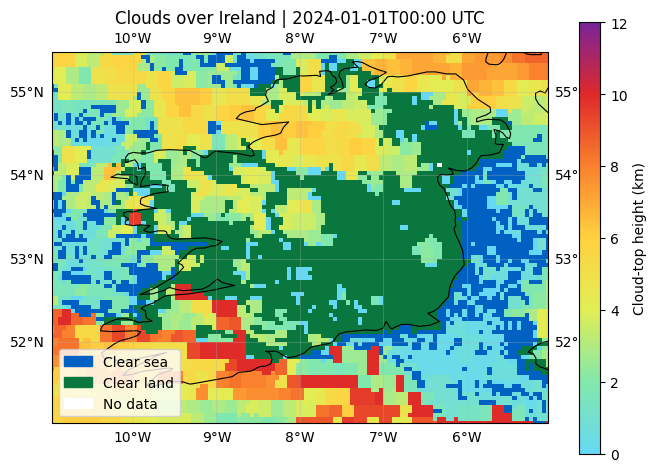

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap
)

# Background categories: sea, land, cloud, no data
background = ListedColormap(["#0161c2", "#09773e", "white", "white"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)

# Same cloud-height colours as the 28-map figure
height_colours = LinearSegmentedColormap.from_list(
    "cloud_height",
    ["#65d9f3", "#82e8aa", "#e2ee54", "#ffd13f",
     "#fa812d", "#df2929", "#79249a"]
)

# Show cloud-top height only where mask code 2 means cloud
cloud_height = np.ma.masked_where(mask != 2, height)

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.pcolormesh(
    lon, lat, mask,
    cmap=background,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree()
)

cloud_plot = ax.pcolormesh(
    lon, lat, cloud_height,
    cmap=height_colours,  # Changed from "Purples"
    vmin=0,
    vmax=12,
    shading="auto",
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution="50m", color="black", linewidth=0.8)
ax.set_extent(
    [lon.min(), lon.max(), lat.min(), lat.max()],
    crs=ccrs.PlateCarree()
)
ax.gridlines(draw_labels=True, alpha=0.3)

fig.colorbar(
    cloud_plot,
    ax=ax,
    shrink=0.7,
    label="Cloud-top height (km)"
)

ax.legend(handles=[
    patches.Patch(color="#0161c2", label="Clear sea"),
    patches.Patch(color="#09773e", label="Clear land"),
    patches.Patch(color="white", label="No data"),
], loc="lower left")

ax.set_title(f"Clouds over Ireland | {str(time)[:16]} UTC")
plt.show()

In [14]:
# Select one week, with an image every 6 hours
start_time = np.datetime64("2024-06-15T00:00:00")

with np.load(cloud_file) as data:
    all_times = data["times"]
    start_index = np.where(all_times == start_time)[0][0]
    positions = np.arange(start_index, start_index + 7 * 24, 6)

    times = all_times[positions]
    masks = data["cloud_mask"][positions]
    heights = data["cth_km"][positions]
    lat = data["lat"]
    lon = data["lon"]

print("Selected images:", len(times))

Selected images: 28


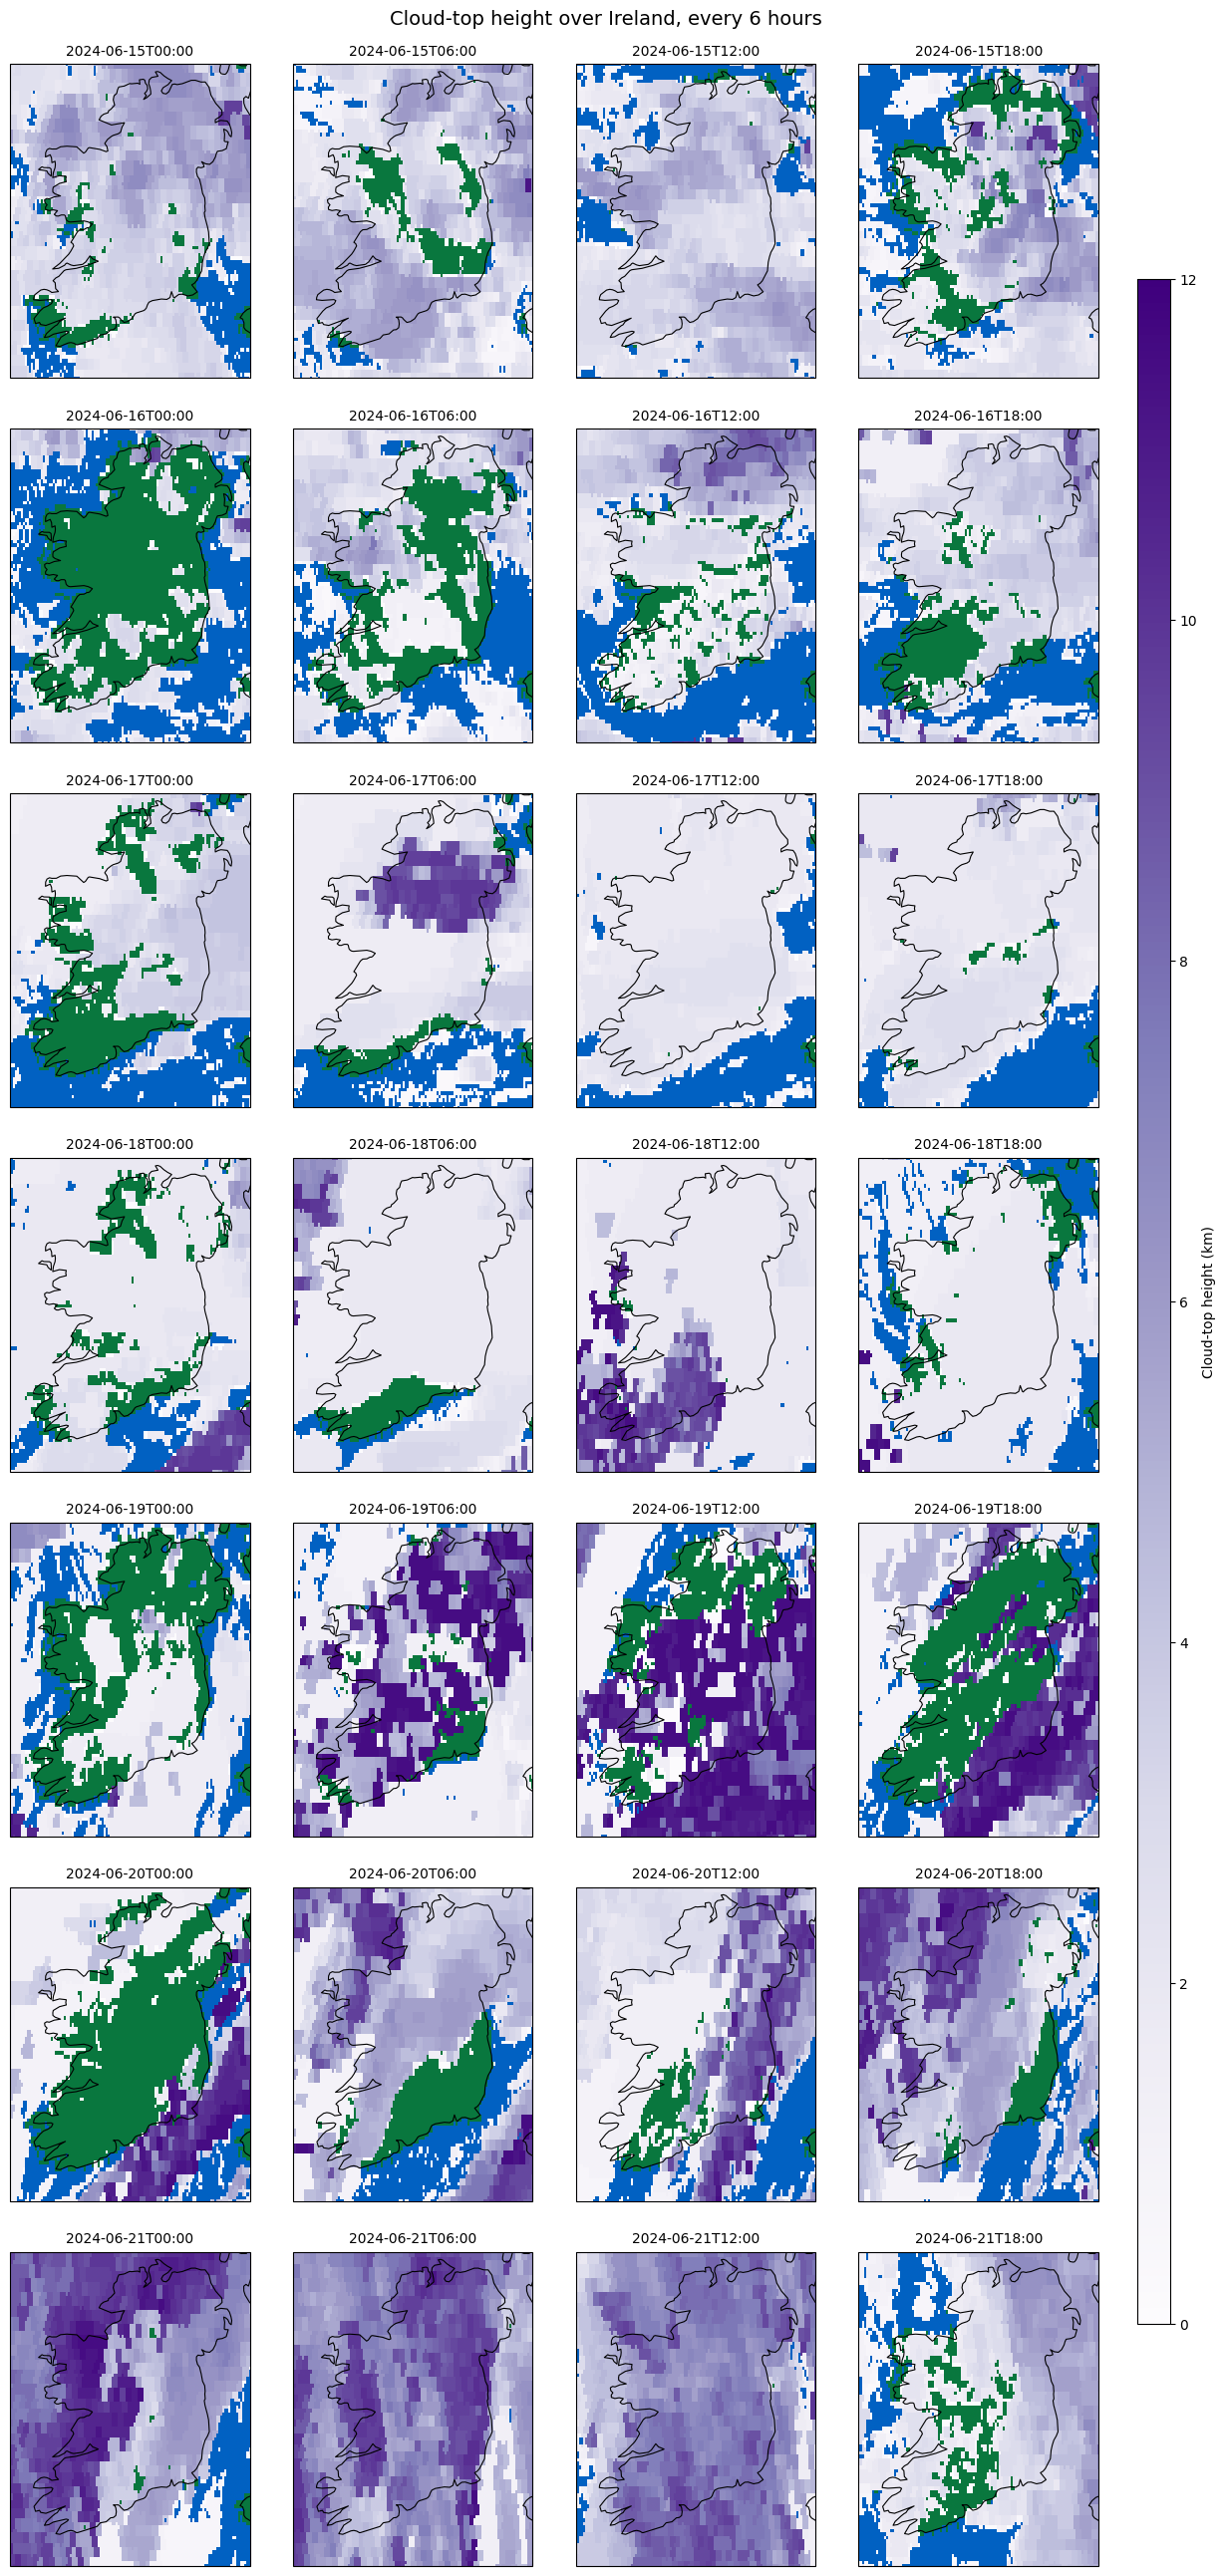

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

# Cloud-mask colours: sea, land, cloud, no data
background = ListedColormap([
    "#0161c2",  # 0: clear sea
    "#09773e",  # 1: clear land
    "#8e63b9",  # 2: cloud
    "#ffffff",  # 3: no data
])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)

fig, axes = plt.subplots(
    7, 4,
    figsize=(13, 27),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Control the gaps between maps and leave room for the colour bar
fig.subplots_adjust(
    left=0.04,
    right=0.88,
    bottom=0.03,
    top=0.96,
    wspace=0.18,
    hspace=0.16
)

for position, ax in enumerate(axes.flat):
    mask = masks[position]
    height = heights[position]

    # Keep height values only at cloudy pixels
    cloud_height = np.ma.masked_where(mask != 2, height)

    ax.pcolormesh(
        lon, lat, mask,
        cmap=background,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    coloured_clouds = ax.pcolormesh(
        lon, lat, cloud_height,
        cmap="Purples",
        vmin=0,
        vmax=12,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m", color="black", linewidth=0.8)
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )

    ax.set_aspect("auto")
    ax.set_title(str(times[position])[:16], fontsize=10)

fig.suptitle("Cloud-top height over Ireland, every 6 hours", fontsize=14)

colourbar_area = fig.add_axes([0.91, 0.12, 0.025, 0.76])
fig.colorbar(
    coloured_clouds,
    cax=colourbar_area,
    label="Cloud-top height (km)"
)

plt.show()